In [2]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = True
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import math
import random

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    UnionFind,
    calc_centroid,
    calc_dist,
    calc_rectangle_area,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_sorted_edges,
    exponential_schedule,
    kruskals_algorithm,
    linear_schedule,
    my_deepcopy,
    prim,
    prim_k,
    prim_vs,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

<!-- やること

- 初期解を生成する

  - グループを 2 つ選ぶ
    - グループを 1 つ選ぶ

- 以下を持つオブジェクト
  - ソート済み辺(cost, a, b)
  - 対象頂点 set
  - 現在のエッジ
  - 正解のエッジ
  - 現在の誤りエッジ数
  - V = len(頂点 set)
  - 辺の更新(input: ソート済み更新辺)
    - 更新辺に含まれているエッジがあれば削除
    - 元の辺と、更新辺を前から捜査していき、小さい順に追加する
    - クラスカル法で現在のエッジを更新
    - V - 正解エッジ数を算出

全辺の総数 = (env.L - 1) / env.Q

- 1 点を更新する
  - cost = 0
  - 1 つの全域木 INFO for 全全域木 INFO
    - その全域木内の点が更新対象でないな
      - cost += 誤りエッジ数
    - 更新対象である
      - 更新点と、全域木内の点の距離を計算してエッジを作成
      - エッジをソート
      - 辺の更新メソッドを呼ぶ
      - cost += 誤りエッジ数
  - total_cost = cost / 全辺の総数 -->


In [3]:
# =================================
# 以下メイン処理
# =================================
class MyGraph:
    def __init__(self, vs, edges, group_ind):
        self.vs = vs
        self.edges = edges
        self.group_ind = group_ind

        self.visited_cnt = {v: 0 for v in vs}
        self._construct_graph()

    def _construct_graph(self):
        graph = {v: [] for v in self.vs}
        for i, e in enumerate(self.edges):
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def update_edges(self, remove_edge, add_edges):
        self.edges = list(set(self.edges) - set(remove_edge) | set(add_edges))
        self._construct_graph()

    def choice_min_visited(self):
        min_v = min(self.visited_cnt.values())
        min_vs = [v for v, cnt in self.visited_cnt.items() if cnt == min_v]
        return random.choice(min_vs)

    def walk_bfs(self, init_v, q_num):
        visited_v = set()
        visited_edge = set()
        q = [(None, init_v)]
        while q and len(visited_v) < q_num:
            random.shuffle(q)
            pv, v = q.pop()
            if v in visited_v:
                continue
            if pv is not None:
                visited_edge.add((min(pv, v), max(pv, v)))
            visited_v.add(v)
            for nv in self.graph[v]:
                if nv not in visited_v:
                    q.append((v, nv))

        for v in visited_v:
            self.visited_cnt[v] += 1

        return visited_v, visited_edge


def define_query_cnt(env: Env, limit_query_cnt=LIMIT_QUERY_CNT):
    group_query_cnt = [0 for _ in range(env.M)]
    group_query_v_cnt = [0 for _ in range(env.M)]

    largest_groups = []
    for g in range(env.M):
        if 3 <= env.G[g]:
            group_query_cnt[g] += 1
            group_query_v_cnt[g] += env.L
            if env.L < env.G[g]:
                largest_groups.append(g)

    for _ri in range(env.Q - sum(group_query_cnt)):
        min_cost = 10**9
        target_group = None
        for g in largest_groups:
            cost = group_query_v_cnt[g] / env.G[g]
            if cost < min_cost:
                min_cost = cost
                target_group = g
        if target_group is not None:
            group_query_v_cnt[target_group] += env.L
            group_query_cnt[target_group] += 1
            if limit_query_cnt is not None and min_cost >= limit_query_cnt:
                break
    return group_query_cnt


def update_mst(
    env: Env,
    ans_v,
    ans_edges,
    group_query_cnt: dict[int, int],
):
    for g in range(env.M):
        now_v = ans_v[g]
        now_edges = ans_edges[g]
        if len(now_v) < 3:
            if group_query_cnt[g] > 0:
                print(g, "ERROR")
        elif 3 <= len(now_v) <= env.L:
            ans_edges[g] = env.query(now_v)
        else:
            my_graph = MyGraph(now_v, now_edges, g)
            for _ in range(group_query_cnt[g]):
                rand_v = my_graph.choice_min_visited()
                visited_v, visited_edge = my_graph.walk_bfs(rand_v, env.L)
                new_edges = env.query(visited_v)
                my_graph.update_edges(visited_edge, new_edges)
            ans_edges[g] = my_graph.edges

    return ans_v, ans_edges


def calc_greedy_answer(env: Env, target_points):
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]
    ans_costs = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, prim_cost = prim_k(graph, v, group_size, now_used, env.N)
        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        ans_costs[group_n] = prim_cost
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges, ans_costs


# =================================
# 焼きなまし
# =================================
def neighbor_function(
    vs,
    costs,
    centroids,
    coords,
    graph,
):
    """近傍解"""
    MAX_G_NUM = 5
    next_vs = my_deepcopy(vs)
    G = len(vs)

    weighted_costs = [cost / len(vs_list) for vs_list, cost in zip(vs, costs)]
    g1 = random.choices(list(range(G)), weights=weighted_costs, k=1)[0]

    # 重心からの距離が近いグループを選ぶ
    now_centroid = centroids[g1]
    dists = [1 / math.dist(centroids[g], now_centroid) for g in range(G) if g != g1]
    other_inds = [g for g in range(G) if g != g1]
    g2 = random.choices(other_inds, weights=dists, k=1)[0]

    g1_num = len(next_vs[g1])
    g2_num = len(next_vs[g2])
    g_num = random.randint(1, min(MAX_G_NUM, min(g1_num, g2_num)))

    v1 = random.sample(next_vs[g1], k=g_num)
    v2 = random.sample(next_vs[g2], k=g_num)

    next_vs[g1] = list(set(next_vs[g1]) - set(v1))
    next_vs[g2] = list(set(next_vs[g2]) - set(v2))
    next_vs[g1] += v2
    next_vs[g2] += v1

    g1_edges, g1_cost = prim_vs(graph, next_vs[g1])
    g2_edges, g2_cost = prim_vs(graph, next_vs[g2])

    g1_centroid = calc_centroid([coords[v] for v in next_vs[g1]])
    g2_centroid = calc_centroid([coords[v] for v in next_vs[g2]])

    return next_vs, [g1, g2], [g1_cost, g2_cost], [g1_edges, g2_edges], [g1_centroid, g2_centroid]


def simulated_annealing(
    x0: list[list[int]],
    t0: float,
    t1: float,
    coords: list[tuple[int, int]],
    ans_edges: list[list[tuple[int, int]]],
    ans_costs: list[float],
    max_time: float,
    display: bool,
):
    x = x0
    graph = construct_dist_matrix(coords)
    costs = ans_costs
    edges = ans_edges
    centroids = []
    for vs_list in x:
        target_coords = [coords[v] for v in vs_list]
        centroid = calc_centroid(target_coords)
        centroids.append(centroid)

    current_cost = sum(costs)

    best_x = x
    best_edges = edges
    best_cost = current_cost

    start_time = time.perf_counter()  # 開始時刻を記録
    iteration = 0
    while True:
        elapsed_time = time.perf_counter() - start_time
        if elapsed_time >= max_time:
            break
        temp = exponential_schedule(t0, t1, elapsed_time, max_time)

        # 近傍解を生成
        new_x, target_groups, target_costs, target_edges, target_centroids = neighbor_function(
            x,
            costs,
            centroids,
            coords,
            graph,
        )

        # 新しいコストを計算
        new_cost = sum(target_costs)
        for g in range(len(new_x)):
            if g in target_groups:
                continue
            new_cost += costs[g]

        # 受け入れ or 拒否
        delta_cost = new_cost - current_cost
        if delta_cost < 0 or random.random() < math.exp(-delta_cost / temp):
            x = new_x
            current_cost = new_cost
            costs[target_groups[0]] = target_costs[0]
            costs[target_groups[1]] = target_costs[1]
            edges[target_groups[0]] = target_edges[0]
            edges[target_groups[1]] = target_edges[1]
            centroids[target_groups[0]] = target_centroids[0]
            centroids[target_groups[1]] = target_centroids[1]

        # 最良解の更新
        if current_cost < best_cost:
            best_x = x
            best_edges = my_deepcopy(edges)
            best_cost = current_cost

        iteration += 1

        if display and iteration % 10000 == 0:
            debug_print(f"Iteration: {iteration}, Best cost: {best_cost}, Current cost: {current_cost}")

    return best_x, best_edges


def solve(env: Env):
    ans_v, ans_edges, ans_costs = calc_greedy_answer(env, env.cneter_points)
    if env.M > 1:
        ans_v, ans_edges = simulated_annealing(
            x0=ans_v,
            t0=5,
            t1=0.1,
            coords=env.cneter_points,
            ans_edges=ans_edges,
            ans_costs=ans_costs,
            max_time=MAX_TIME,
            display=True,
        )
    ans_v, ans_edges = update_mst(
        env,
        ans_v,
        ans_edges,
        define_query_cnt(env),
    )
    return env.answer(ans_v, ans_edges)

In [4]:
file_num = 0
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [5]:
ans_v, ans_edges, ans_costs = calc_greedy_answer(env, env.cneter_points)
ans_v, ans_edges = simulated_annealing(
    x0=ans_v,
    t0=5,
    t1=0.1,
    coords=env.cneter_points,
    ans_edges=ans_edges,
    ans_costs=ans_costs,
    max_time=1,
    display=True,
)
ans_v, ans_edges = update_mst(
    env,
    ans_v,
    ans_edges,
    define_query_cnt(env),
)

In [6]:
import numpy as np

corrects = np.array(env.coordinates)
centers = np.array(env.cneter_points)
print("score", env.answer(ans_v, ans_edges))

query: 400
score 281516.0


In [7]:
print(env.L, env.M, env.W)
print(env.G)

3 113 1367
[5, 5, 1, 22, 7, 4, 1, 2, 6, 11, 8, 4, 1, 13, 2, 4, 1, 3, 18, 1, 2, 28, 5, 6, 2, 25, 3, 7, 4, 3, 3, 5, 14, 4, 3, 11, 14, 2, 2, 10, 4, 1, 4, 23, 9, 15, 5, 14, 8, 3, 17, 8, 5, 9, 5, 8, 3, 1, 3, 6, 1, 7, 7, 4, 3, 7, 1, 1, 3, 4, 14, 1, 19, 18, 5, 5, 13, 1, 2, 6, 9, 6, 1, 9, 20, 1, 1, 8, 18, 14, 8, 5, 6, 7, 2, 10, 7, 11, 3, 3, 23, 2, 4, 6, 9, 3, 2, 2, 1, 25, 14, 3, 12]


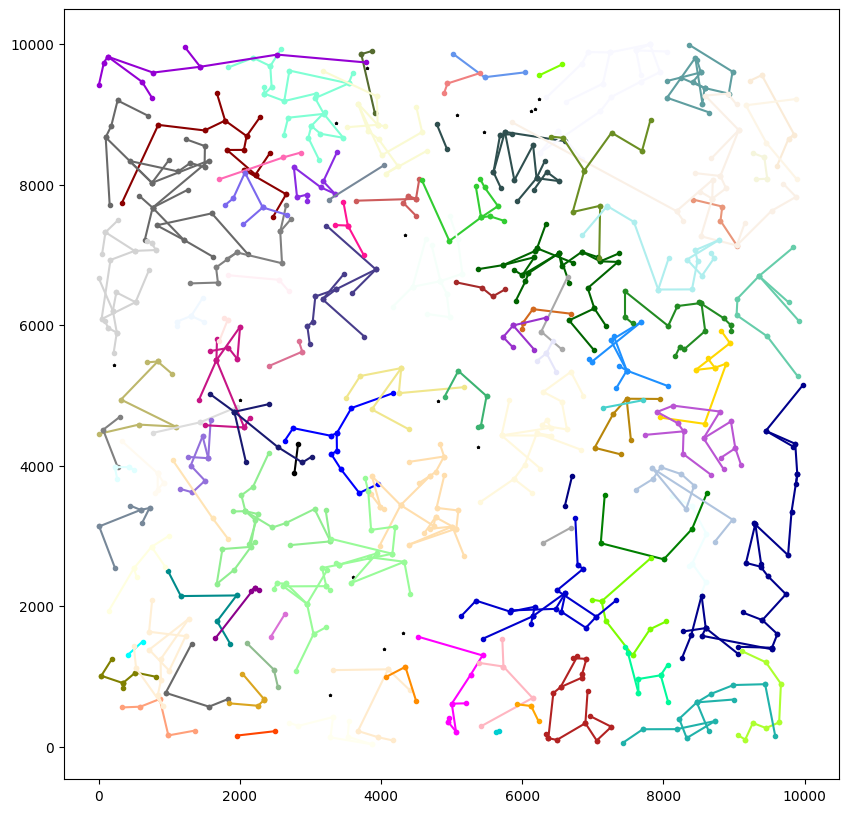

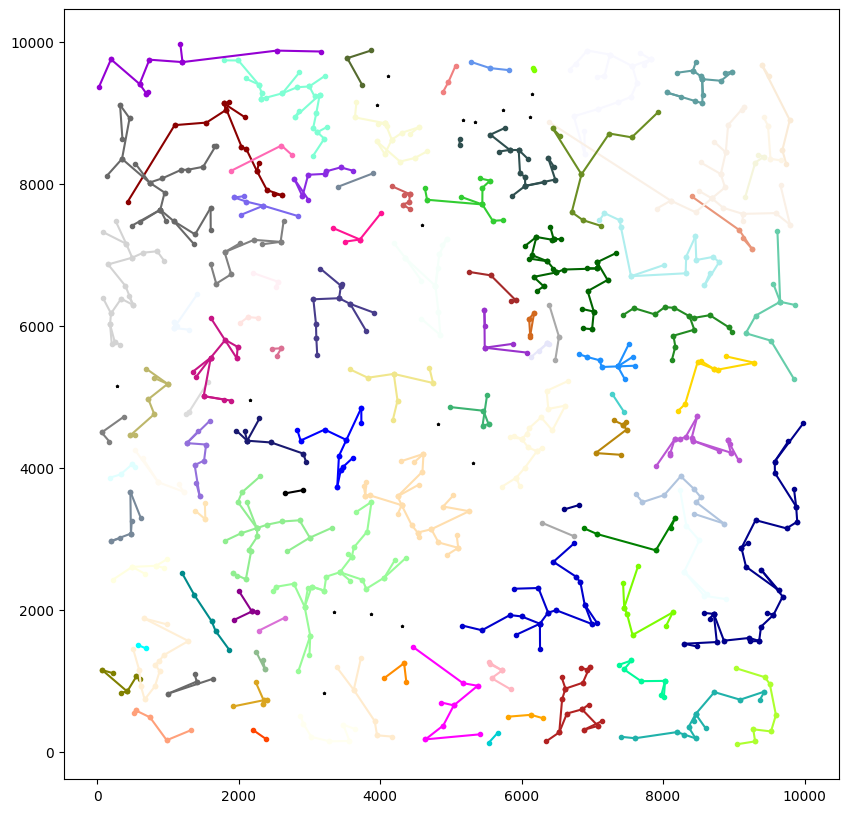

In [8]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# def get_color(i):
#     colors = plt.get_cmap("tab30").colors
#     return colors[i % len(colors)]


def get_color(i):
    colors = list(matplotlib.colors.CSS4_COLORS.values())
    return colors[i % len(colors)]


def draw_answer(ans_v, ans_edges, correct_coords):
    correct_coords = np.array(correct_coords)

    plt.figure(figsize=(10, 10))

    for g, (vs, edges) in enumerate(zip(ans_v, ans_edges)):
        if len(vs) == 1:
            coord = correct_coords[vs][0]
            plt.scatter(coord[0], coord[1], color="black", marker="*", s=3)
        vs = np.array(vs)
        edges = np.array(edges)
        for e in edges:
            cs = correct_coords[e]
            plt.plot(
                cs[:, 0],
                cs[:, 1],
                color=get_color(g),
                marker="o",
                markersize=3,
            )
    plt.show()


draw_answer(ans_v, ans_edges, env.coordinates)
draw_answer(ans_v, ans_edges, env.cneter_points)
# draw_answer(anv_v_estimate, ans_edges_estimate, env.coordinates)
# draw_answer(anv_v_simulate, ans_edges_simulate, env.coordinates)

In [9]:
# point_inds = list(range(env.N))  # longs_points[:]
# corrects_np = np.array(corrects)[point_inds]
# estimates_np = np.array(estimates)[point_inds]
# rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# # 四角形と、四角形内の正解点と予測点を描画
# plt.figure(figsize=(10, 10))
# ax = plt.gca()
# # for i, rect in enumerate(rectangles):
# #     l, r, t, b = rect
# #     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
# ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
# ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
# for point_ind in range(len(corrects_np)):
#     ax.plot(
#         (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
#         (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
#         color="gray",
#         label="correct path",
#     )
# plt.show()